# Bahrain Non-Oil Foreign Trade — Exploratory Data Analysis

**Author:** Aqeel Ebrahim &nbsp;|&nbsp; **Cohort:** Data Science DSB-1
**Topic 22 — Import & Export (Bahrain)**

---

## Introduction
**Introduction to the topic**

The Kingdom of Bahrain is a small, open, oil-exporting economy in the Arabian Gulf that is actively pursuing
economic diversification under its **Economic Vision 2030**. Foreign trade is central to that story: what the
country buys from the world, what it manufactures and sells, and whether its **non-oil** sector can stand on its
own weight.

This project explores Bahrain's official **non-oil foreign-trade records** — every import, export and re-export
transaction classified by **commodity (HS code)** and **partner country** — published on the
[Bahrain Open Data Portal](https://www.data.gov.bh/explore/?refine.theme=Foreign+Trade). We combine several
datasets:

* An **annual foreign-trade summary** (2010–2023) with the headline totals, in million Bahraini Dinar (BD).
* **Transaction-level** non-oil datasets for **2023 and 2024** covering imports, total exports, national-origin
  exports and re-exports.

All monetary values are reported in **Bahraini Dinar (BD)**; the portal also provides a USD equivalent
(BD is pegged at ≈ 2.659 USD).

---

## Problem Statement

Bahrain reports a **headline trade surplus** — its overall balance swung from five consecutive deficit years
(2016–2020) to a record **+2,516 million BD** surplus in 2022 — but these totals are heavily influenced by **oil**.
When oil is stripped out, the picture reverses: in **2024** Bahrain imported **≈ 5,872 million BD** of non-oil
goods while exporting only **≈ 4,682 million BD**, a **non-oil trade deficit of roughly 1,190 million BD**.

For an economy pursuing diversification under Vision 2030, the *structure* of this non-oil trade — **which
commodities and partners drive it, how concentrated and seasonal it is, and how it is changing** — is decisive
but is not visible in the raw, 300,000-row-per-file open data. This project cleans and analyses those records to
make the structure clear and to show where the diversification and trade-balance **risks and opportunities** lie.

*Audience:* trade-strategy stakeholders such as the **Bahrain Economic Development Board** and the **Ministry of
Industry & Commerce** who need an evidence base for diversification decisions.

---

## Objectives
**Questions that will guide the analysis to solve the problem**

1. **Long-term trend** — How has Bahrain's total (oil-inclusive) trade — imports, exports and the resulting
   **trade balance** — evolved year-on-year from **2010 to 2023**, and when did the balance shift between deficit
   and surplus? *(Change over time / Deviation)*
2. **Non-oil balance & composition** — In **2024**, what is the **non-oil** trade balance, and how are exports
   split between **national-origin exports** and **re-exports**? *(Part-to-whole)*
3. **Partner concentration** — Which **partner countries** dominate non-oil imports and exports in 2024, and what
   share do the **top 5** hold? *(Ranking / Magnitude)*
4. **Commodity structure** — Which **commodities** and **HS product groups** account for the largest shares of
   non-oil imports and exports in 2024? *(Ranking / Part-to-whole)*
5. **Concentration** — How concentrated is non-oil trade — what **percentage of commodities** accounts for **80%**
   of trade value? *(Distribution)*
6. **Seasonality** — Is there a **monthly** pattern in non-oil imports and exports during 2024?
   *(Change over time)*
7. **Year-on-year change** — Which **partners and commodities grew or declined** the most between **2023 and 2024**?
   *(Ranking / Deviation)*

We also apply **inferential statistics** to test whether transaction **value** is associated with **shipment
weight**, and whether **import and export** transaction sizes differ significantly.

---

## Exploratory Data Analysis (EDA)

### Data Info
**Getting the data and exploring it (includes descriptive statistics)**

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Display + plotting configuration
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.size": 11,
})

# Consistent colour scheme used across the whole project
C_IMPORT = "#4C72B0"   # blue
C_EXPORT = "#DD8452"   # orange
C_POS    = "#55A868"   # green  (surplus / growth)
C_NEG    = "#C44E52"   # red    (deficit / decline)
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Relative paths (keeps the notebook reproducible for anyone who clones the repo)
from pathlib import Path
RAW      = Path("data") / "raw"
CLEANED  = Path("data") / "cleaned"
IMAGES   = Path("images")
CLEANED.mkdir(parents=True, exist_ok=True)
IMAGES.mkdir(parents=True, exist_ok=True)
sorted(p.name for p in RAW.glob("*.csv"))

['annual_foreign_trade_statistics.csv',
 'imports_2023.csv',
 'imports_2024.csv',
 'national_exports_2024.csv',
 're_exports_2024.csv',
 'total_exports_2023.csv',
 'total_exports_2024.csv']

In [3]:
# --- Annual summary (2010-2023), values already aggregated in million BD ---
annual_raw = pd.read_csv(RAW / "annual_foreign_trade_statistics.csv", sep=";")
print("Annual summary shape:", annual_raw.shape)
annual_raw.head()

Annual summary shape: (168, 4)


,year,hst_ltjr_lkhrjy_lsnwy,annual_foreign_trade_statistics,value_million_bd
0,2010,إعادة تصدير,Re_Exports,229.140000
1,2010,إجمالي الصادرات,Total Exports,6282.348842
2,2010,الواردات النفطية,oil Imports,2514.171776
3,2010,إجمالي الواردات,Total Imports,6328.043293
4,2010,الميزان التجاري للبيانات الغير النفطية,Trade balance,-1857.391516


In [4]:
# The transaction-level files are large (~320k rows each). Preview ONE raw import
# file to see the real structure we have to clean.
imp24_raw = pd.read_csv(RAW / "imports_2024.csv", sep=";", dtype=str, nrows=5)
print("imports_2024 columns:", list(imp24_raw.columns))
imp24_raw

imports_2024 columns: ['n', 'month', 'lshhr', 'commodity_no', 'commodity', 'lsl', 'un_code', 'country_name', 'ldwl', 'qym_lwrdt_dynr_bhryny', 'qym_lwrdt_dwlr_mryky', 'wzn_lwrdt_kjm', 'kmy_lwrdt', 'whd_lqys']


,n,month,lshhr,commodity_no,commodity,lsl,un_code,country_name,ldwl,qym_lwrdt_dynr_bhryny,qym_lwrdt_dwlr_mryky,wzn_lwrdt_kjm,kmy_lwrdt,whd_lqys
0,1,01-January,01 يناير,01012910,HORSES FOR SPORT,خيول للرياضة,NL,NETHERLANDS,هولندا,1483.37,3945.14,400.0,2.0,NO
1,2,01-January,01 يناير,01012910,HORSES FOR SPORT,خيول للرياضة,DE,GERMANY,ألمانيا,1539.15,4093.48,400.0,2.0,NO
2,3,01-January,01 يناير,01012910,HORSES FOR SPORT,خيول للرياضة,GB,UNITED KINGDOM,المملكة المتحدة,4486.69,11932.69,1950.0,4.0,NO
3,4,01-January,01 يناير,01012910,HORSES FOR SPORT,خيول للرياضة,AE,UNITED ARAB EMIRATES,الامارات العربية المتحدة,4980.18,13245.15,4600.0,12.0,NO
4,5,01-January,01 يناير,01022900,OTHER BOVINE,غيرها من ابقار,OM,SULTANATE OMAN,سلطنة عمان,289893.48,770993.29,206600.0,1053.0,NO


In [5]:
# Compare the column headers across the six transaction files: they are NOT consistent.
detail_files = ["imports_2023", "imports_2024", "total_exports_2023",
                "total_exports_2024", "national_exports_2024", "re_exports_2024"]
for f in detail_files:
    cols = pd.read_csv(RAW / f"{f}.csv", sep=";", nrows=0).columns.tolist()
    print(f"{f:22s} ({len(cols)} cols): {cols}")

imports_2023           (14 cols): ['year', 'month', 'lshhr', 'commodity_no', 'commodity', 'lsl', 'un_code', 'country_name', 'ldwl', 'import_value_bd', 'import_value_usa', 'import_weight_kg', 'import_quantity', 'um']
imports_2024           (14 cols): ['n', 'month', 'lshhr', 'commodity_no', 'commodity', 'lsl', 'un_code', 'country_name', 'ldwl', 'qym_lwrdt_dynr_bhryny', 'qym_lwrdt_dwlr_mryky', 'wzn_lwrdt_kjm', 'kmy_lwrdt', 'whd_lqys']
total_exports_2023     (14 cols): ['year', 'month', 'lshhr', 'commodity_no', 'commodity', 'lsl', 'un_code', 'country_name', 'ldwl', 'export_value_bd', 'export_value_usa', 'export_weight_kg', 'export_quantity', 'um']
total_exports_2024     (15 cols): ['n', 'year', 'month', 'lshhr', 'commodity_no', 'commodity', 'lsl', 'un_code', 'country_name', 'ldwl', 'export_value_bd', 'export_value_usa', 'export_weight_kg', 'export_quantity', 'um']
national_exports_2024  (15 cols): ['n', 'year', 'month', 'lshhr', 'commodity_no', 'commodity', 'lsl', 'un_code', 'country_name'

**Observations from the raw data**

* **Inconsistent schema.** `imports_2024` uses Arabic-transliterated headers (`qym_lwrdt_dynr_bhryny` = value in BD,
  `wzn_lwrdt_kjm` = weight, …), has **no `year` column**, and writes months as `01-January` (hyphen) instead of
  `01 January`.
* **Duplicate Arabic columns** — `lshhr` (month), `lsl` (commodity) and `ldwl` (country) repeat the English columns
  and can be dropped. Some files carry an index column `n`.
* **Numbers stored as text** with very high precision; `commodity_no` must stay a **string** to preserve HS-code
  leading zeros (e.g. `01012910`).
* The annual file has **two conflicting spellings** — `Trade Balance` and `Trade balance` — with different values.

We fix all of these in the next section.

### Data Handling
**Cleaning, transforming, and combining data**

In [6]:
# Map every header variant onto ONE consistent schema
RENAME = {
    # exports
    "export_value_bd": "value_bd", "export_value_usa": "value_usa",
    "export_weight_kg": "weight_kg", "export_quantity": "quantity",
    # imports (English headers, 2023)
    "import_value_bd": "value_bd", "import_value_usa": "value_usa",
    "import_weight_kg": "weight_kg", "import_quantity": "quantity",
    # imports (Arabic-transliterated headers, 2024)
    "qym_lwrdt_dynr_bhryny": "value_bd", "qym_lwrdt_dwlr_mryky": "value_usa",
    "wzn_lwrdt_kjm": "weight_kg", "kmy_lwrdt": "quantity", "whd_lqys": "um",
}
DROP = ["n", "lshhr", "lsl", "ldwl"]        # index + Arabic duplicate columns

def load_detail(fname, flow, year_default=None):
    """Load one transaction-level file and return it in a clean, common schema."""
    df = pd.read_csv(RAW / f"{fname}.csv", sep=";", dtype=str)
    df = df.rename(columns=RENAME).drop(columns=[c for c in DROP if c in df.columns])

    # imports_2024 has no year column -> set it explicitly
    if "year" not in df.columns:
        df["year"] = year_default

    # Month: extract the number (1-12) and the English name from '01 January' / '01-January'
    df["month_num"]  = df["month"].str.extract(r"(\d+)").astype(int)
    df["month_name"] = df["month"].str.extract(r"([A-Za-z]+)")

    # Convert the value / weight / quantity columns from text to numbers
    for c in ["value_bd", "value_usa", "weight_kg", "quantity"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # Tidy the text columns; Title-case names so 'IRAQ' and 'Iraq' aggregate together
    df["commodity_no"] = df["commodity_no"].astype(str).str.strip()
    df["commodity"]    = df["commodity"].str.strip().str.title()
    df["country_name"] = df["country_name"].str.strip().str.title()

    # Feature engineering
    df["hs_chapter"] = df["commodity_no"].str[:2]     # HS chapter = first 2 digits
    df["flow"]       = flow

    keep = ["year", "month_num", "month_name", "commodity_no", "commodity", "hs_chapter",
            "un_code", "country_name", "value_bd", "value_usa", "weight_kg", "quantity", "um", "flow"]
    return df[keep]

print("load_detail() defined.")

load_detail() defined.


In [7]:
# Load and clean all six transaction datasets
imp23  = load_detail("imports_2023",         "Import",          2023)
imp24  = load_detail("imports_2024",         "Import",          2024)
texp23 = load_detail("total_exports_2023",   "Total Export",    2023)
texp24 = load_detail("total_exports_2024",   "Total Export",    2024)
nexp24 = load_detail("national_exports_2024","National Export", 2024)
rexp24 = load_detail("re_exports_2024",      "Re-export",       2024)

for name, d in [("imports_2023", imp23), ("imports_2024", imp24),
                ("total_exports_2023", texp23), ("total_exports_2024", texp24),
                ("national_exports_2024", nexp24), ("re_exports_2024", rexp24)]:
    print(f"{name:22s} -> {d.shape[0]:>7,} rows")

imports_2023           -> 321,376 rows
imports_2024           -> 322,062 rows
total_exports_2023     ->  59,345 rows
total_exports_2024     ->  60,400 rows
national_exports_2024  ->  18,521 rows
re_exports_2024        ->  45,647 rows


In [8]:
# Combine the directly comparable flows (imports + total exports) into one tidy frame.
# National-origin and re-export are kept separate (they are components of Total Export).
trade = pd.concat([imp23, imp24, texp23, texp24], ignore_index=True)
print("Combined trade frame:", trade.shape)
trade.head()

Combined trade frame: (763183, 14)


,year,month_num,month_name,commodity_no,commodity,hs_chapter,un_code,country_name,value_bd,value_usa,weight_kg,quantity,um,flow
0,2023,1,January,48062000,Greaseproof Papers,48,AE,United Arab Emirates,3012.141,8011.013298,2741.50,2741.50,KG,Import
1,2023,1,January,48062000,Greaseproof Papers,48,FR,France,1259.535,3349.827128,500.00,500.00,KG,Import
2,2023,1,January,48062000,Greaseproof Papers,48,GB,United Kingdom,295.387,785.603723,150.50,150.50,KG,Import
3,2023,1,January,48062000,Greaseproof Papers,48,US,United States Of America,81.002,215.430851,40.00,40.00,KG,Import
4,2023,1,January,48064000,Glassine And Other Glazed Transparent Paper,48,ES,Spain,4.072,10.829787,1.64,1.64,KG,Import


In [9]:
# Cleaned data types and a quick statistical summary of the numeric columns
trade.info()
print()
trade[["value_bd", "value_usa", "weight_kg", "quantity"]].describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 763183 entries, 0 to 763182
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          763183 non-null  Int64  
 1   month_num     763183 non-null  int64  
 2   month_name    763183 non-null  str    
 3   commodity_no  763183 non-null  str    
 4   commodity     763183 non-null  str    
 5   hs_chapter    763183 non-null  str    
 6   un_code       762989 non-null  str    
 7   country_name  763183 non-null  str    
 8   value_bd      763183 non-null  float64
 9   value_usa     763183 non-null  float64
 10  weight_kg     763183 non-null  float64
 11  quantity      763183 non-null  float64
 12  um            763183 non-null  str    
 13  flow          763183 non-null  str    
dtypes: Int64(1), float64(4), int64(1), str(8)
memory usage: 140.9 MB



,value_bd,value_usa,weight_kg,quantity
count,763183.00,7.631830e+05,7.631830e+05,7.631830e+05
mean,27513.30,7.316356e+04,1.116948e+05,1.065051e+05
std,457557.71,1.216783e+06,6.341628e+06,6.248426e+06
min,0.00,0.000000e+00,0.000000e+00,0.000000e+00
25%,119.71,3.183100e+02,1.106000e+01,7.460000e+00
50%,690.46,1.836030e+03,9.667000e+01,6.675000e+01
75%,4469.34,1.188332e+04,1.125440e+03,8.400000e+02
max,75716559.44,2.013738e+08,1.668217e+09,1.668217e+09


In [10]:
# Data-quality checks -------------------------------------------------
print("Missing values per column:")
print(trade.isna().sum())
print("\nFully-duplicated rows:", trade.duplicated().sum())

# Integrity check: Total Exports 2024 should equal National-origin + Re-exports 2024
te = texp24["value_bd"].sum()
nr = nexp24["value_bd"].sum() + rexp24["value_bd"].sum()
print(f"\nIntegrity check (2024, million BD):")
print(f"  Total Export        = {te/1e6:,.2f}")
print(f"  National + Re-export= {nr/1e6:,.2f}")
print(f"  difference          = {(te-nr)/1e6:+.4f}   (should be ~0)")

Missing values per column:
year              0
month_num         0
month_name        0
commodity_no      0
commodity         0
hs_chapter        0
un_code         194
country_name      0
value_bd          0
value_usa         0
weight_kg         0
quantity          0
um                0
flow              0
dtype: int64

Fully-duplicated rows: 0

Integrity check (2024, million BD):
  Total Export        = 4,682.35
  National + Re-export= 4,682.35
  difference          = -0.0000   (should be ~0)


In [11]:
# Clean the annual summary: standardise the messy category labels WITHOUT merging
# distinct series, then recompute Trade Balance ourselves (the reported one is unreliable).
annual = annual_raw.copy()
annual["value_million_bd"] = pd.to_numeric(annual["value_million_bd"], errors="coerce")
annual["year"] = pd.to_numeric(annual["year"], errors="coerce")

cat_map = {
    "Total Imports": "Total Imports", "Total Exports": "Total Exports",
    "Non_Oil Imports": "Non-oil Imports", "Non_oil Exports": "Non-oil Exports",
    "oil Imports": "Oil Imports", "Oil Exports": "Oil Exports",
    "Re_Exports": "Re-exports", "Trade Exchange": "Trade Exchange",
}
annual["category"] = annual["annual_foreign_trade_statistics"].str.strip().map(cat_map)
annual = annual.dropna(subset=["category"])            # drops the ambiguous 'Trade Balance/balance' rows

annual_wide = annual.pivot_table(index="year", columns="category",
                                 values="value_million_bd", aggfunc="sum")
# Recompute the balance consistently
annual_wide["Trade Balance"] = annual_wide["Total Exports"] - annual_wide["Total Imports"]
annual_wide = annual_wide.sort_index()
annual_wide.tail()

category,Non-oil Exports,Non-oil Imports,Oil Exports,Oil Imports,Re-exports,Total Exports,Total Imports,Trade Exchange,Trade Balance
year,,,,,,,,,
2019,2297.685083,4984.103641,3719.598371,2005.377771,794.872635,6812.156089,6989.481412,13801.637501,-177.325323
2020,2387.171545,4797.605699,2232.861624,1043.948090,675.723917,5295.757086,5841.553789,11137.310875,-545.796703
2021,3993.603143,5315.807652,3737.542149,1782.437348,679.440672,8410.585964,7098.245001,15508.830964,1312.340963
2022,4966.768646,5841.900000,5665.900000,2995.030665,720.238844,11352.907490,8836.930665,20189.838155,2515.976825
2023,3909.200000,5777.900000,4664.900000,2436.739700,755.800000,9329.900000,8214.639700,17544.539700,1115.260300


In [12]:
# Save cleaned outputs (relative paths) for the repo, dashboard and README
annual_wide.to_csv(CLEANED / "annual_trade_clean.csv")

# Aggregated 2024 tables (small, tidy, reused by the Streamlit dashboard)
imp24.groupby("country_name", as_index=False)["value_bd"].sum().to_csv(CLEANED / "imports_by_country_2024.csv", index=False)
texp24.groupby("country_name", as_index=False)["value_bd"].sum().to_csv(CLEANED / "exports_by_country_2024.csv", index=False)
imp24.groupby("commodity", as_index=False)["value_bd"].sum().to_csv(CLEANED / "imports_by_commodity_2024.csv", index=False)
texp24.groupby("commodity", as_index=False)["value_bd"].sum().to_csv(CLEANED / "exports_by_commodity_2024.csv", index=False)
print("Cleaned files written to", CLEANED)
sorted(p.name for p in CLEANED.glob("*.csv"))

Cleaned files written to data\cleaned


['annual_trade_clean.csv',
 'dash_commodity_year.csv',
 'dash_country_year.csv',
 'dash_export_composition_2024.csv',
 'dash_month_year.csv',
 'exports_by_commodity_2024.csv',
 'exports_by_country_2024.csv',
 'imports_by_commodity_2024.csv',
 'imports_by_country_2024.csv']

### Analysis
**Answering the objectives through data analysis**

#### Objective 1 — Long-term trade trend and balance (2010–2023)

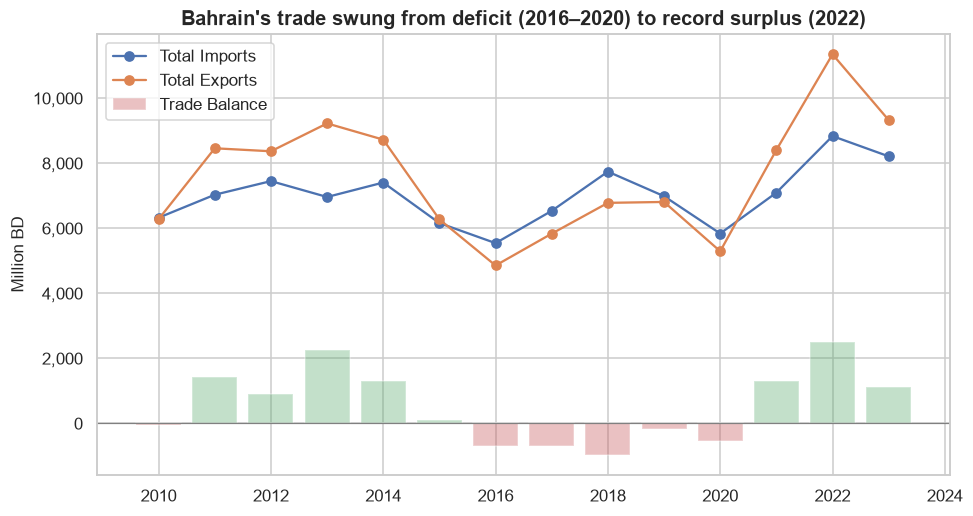

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(annual_wide.index, annual_wide["Total Imports"], marker="o", color=C_IMPORT, label="Total Imports")
ax.plot(annual_wide.index, annual_wide["Total Exports"], marker="o", color=C_EXPORT, label="Total Exports")
bal = annual_wide["Trade Balance"]
ax.bar(annual_wide.index, bal, color=[C_POS if v >= 0 else C_NEG for v in bal], alpha=0.35, label="Trade Balance")
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Bahrain's trade swung from deficit (2016–2020) to record surplus (2022)")
ax.set_ylabel("Million BD")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="upper left", frameon=True)
plt.savefig(IMAGES / "obj1_annual_trend.png")
plt.show()

In [14]:
# Which years were deficits vs surpluses? (masking + sorting)
summary = annual_wide[["Total Imports", "Total Exports", "Trade Balance"]].round(1)
deficit_years = summary.index[summary["Trade Balance"] < 0].tolist()
print("Deficit years:", deficit_years)
print("Largest deficit:", summary["Trade Balance"].idxmin(), f"({summary['Trade Balance'].min():,.0f} M BD)")
print("Largest surplus:", summary["Trade Balance"].idxmax(), f"({summary['Trade Balance'].max():,.0f} M BD)")

Deficit years: [2010, 2016, 2017, 2018, 2019, 2020]
Largest deficit: 2018 (-960 M BD)
Largest surplus: 2022 (2,516 M BD)


**Insight.** Bahrain ran a **trade deficit for five consecutive years (2016–2020)**, bottoming at
**−960 M BD in 2018**, and both flows collapsed in the 2020 pandemic year. Trade then rebounded sharply into a
**record +2,516 M BD surplus in 2022** before cooling in 2023 — a swing driven largely by oil prices, which
motivates isolating the **non-oil** economy next.

#### Objective 1b — How much of the surplus is oil?

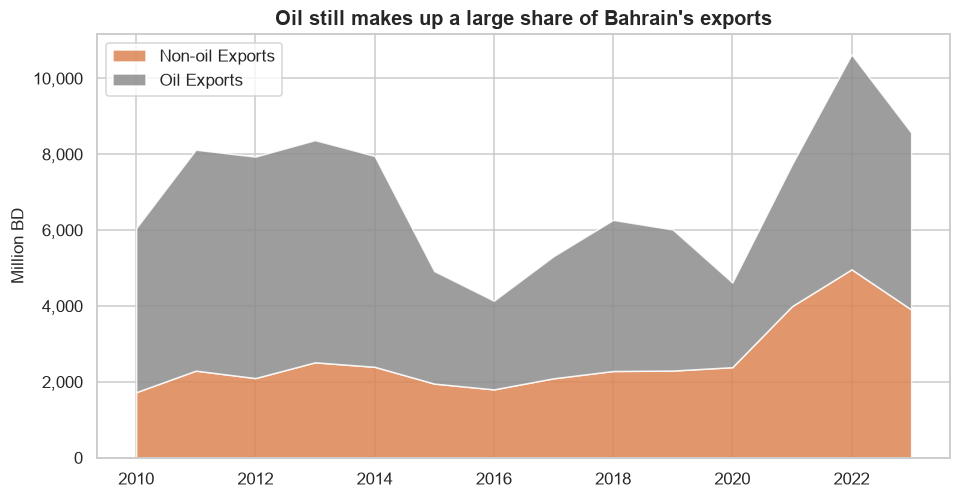

In [15]:
oil_cols = ["Oil Exports", "Non-oil Exports"]
have = [c for c in oil_cols if c in annual_wide.columns]
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(annual_wide.index,
             annual_wide["Non-oil Exports"], annual_wide["Oil Exports"],
             labels=["Non-oil Exports", "Oil Exports"], colors=[C_EXPORT, "#8C8C8C"], alpha=0.85)
ax.set_title("Oil still makes up a large share of Bahrain's exports")
ax.set_ylabel("Million BD")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="upper left")
plt.savefig(IMAGES / "obj1b_oil_vs_nonoil.png")
plt.show()

**Insight.** A substantial part of export value is **oil**. Because the transaction-level datasets are
**non-oil only**, the remaining objectives describe the diversified economy Bahrain is trying to grow — where,
as we will see, the balance looks very different.

#### Objective 2 — Non-oil trade balance and export composition (2024)

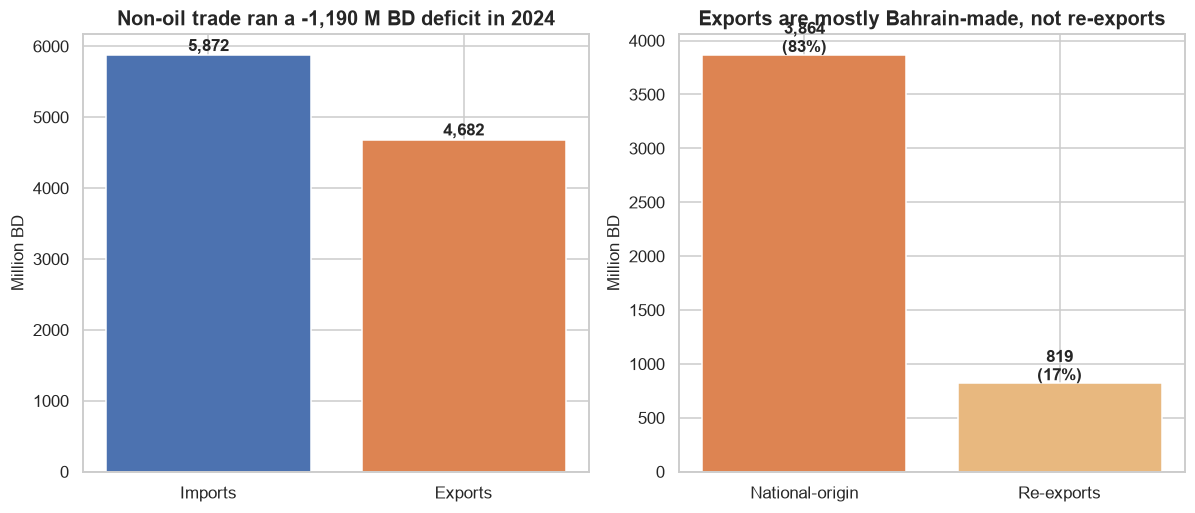

Imports 5,872 | Exports 4,682 | Balance -1,190 M BD
National-origin 83% | Re-exports 17%


In [16]:
imp_total = imp24["value_bd"].sum() / 1e6
exp_total = texp24["value_bd"].sum() / 1e6
nat_total = nexp24["value_bd"].sum() / 1e6
re_total  = rexp24["value_bd"].sum() / 1e6
balance   = exp_total - imp_total

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
# (a) imports vs exports
axes[0].bar(["Imports", "Exports"], [imp_total, exp_total], color=[C_IMPORT, C_EXPORT])
axes[0].set_title(f"Non-oil trade ran a {balance:,.0f} M BD deficit in 2024")
axes[0].set_ylabel("Million BD")
for i, v in enumerate([imp_total, exp_total]):
    axes[0].text(i, v + 60, f"{v:,.0f}", ha="center", fontweight="bold")
# (b) export composition
axes[1].bar(["National-origin", "Re-exports"], [nat_total, re_total], color=[C_EXPORT, "#E8B87F"])
axes[1].set_title("Exports are mostly Bahrain-made, not re-exports")
axes[1].set_ylabel("Million BD")
for i, v in enumerate([nat_total, re_total]):
    axes[1].text(i, v + 30, f"{v:,.0f}\n({v/exp_total*100:.0f}%)", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES / "obj2_balance_composition.png")
plt.show()
print(f"Imports {imp_total:,.0f} | Exports {exp_total:,.0f} | Balance {balance:,.0f} M BD")
print(f"National-origin {nat_total/exp_total*100:.0f}% | Re-exports {re_total/exp_total*100:.0f}%")

**Insight.** Excluding oil, Bahrain **imported ≈ 5,872 M BD but exported only ≈ 4,682 M BD in 2024 — a
non-oil deficit of ≈ 1,190 M BD**. Encouragingly, **~83% of exports are national-origin** (genuinely made in
Bahrain) rather than re-exports, so the export base reflects real domestic production.

#### Objective 3 — Which partner countries dominate trade? (2024)

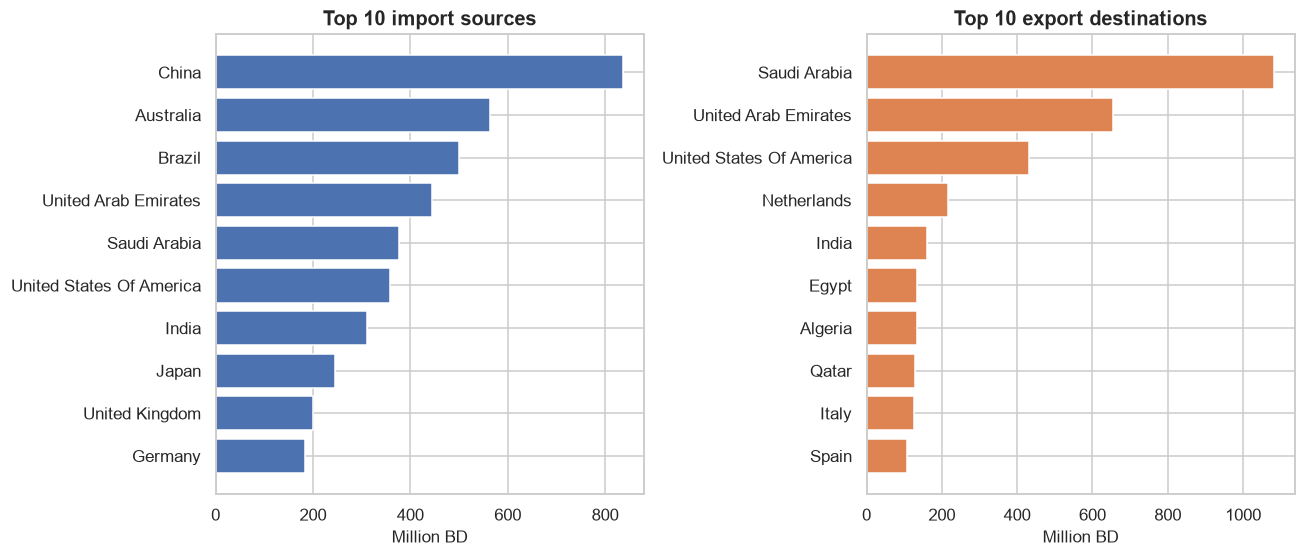

Top-5 partners hold 46% of imports and 54% of exports.


In [17]:
top_imp_ctry = imp24.groupby("country_name")["value_bd"].sum().sort_values(ascending=False).head(10) / 1e6
top_exp_ctry = texp24.groupby("country_name")["value_bd"].sum().sort_values(ascending=False).head(10) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
axes[0].barh(top_imp_ctry.index[::-1], top_imp_ctry.values[::-1], color=C_IMPORT)
axes[0].set_title("Top 10 import sources")
axes[1].barh(top_exp_ctry.index[::-1], top_exp_ctry.values[::-1], color=C_EXPORT)
axes[1].set_title("Top 10 export destinations")
for ax in axes:
    ax.set_xlabel("Million BD")
plt.tight_layout()
plt.savefig(IMAGES / "obj3_top_partners.png")
plt.show()

imp_top5 = top_imp_ctry.head(5).sum() / (imp24['value_bd'].sum()/1e6) * 100
exp_top5 = top_exp_ctry.head(5).sum() / (texp24['value_bd'].sum()/1e6) * 100
print(f"Top-5 partners hold {imp_top5:.0f}% of imports and {exp_top5:.0f}% of exports.")

**Insight.** **Exports are regionally concentrated** — **Saudi Arabia and the UAE alone** lead the list and the
top-5 destinations take **~54%** of non-oil exports, underlining heavy reliance on GCC neighbours. **Imports are
more diversified** by source (top-5 ~46%), led by **China, Australia and Brazil** — the latter two supplying the
raw materials behind Bahrain's metals industry.

#### Objective 4 — Which commodities and product groups drive trade? (2024)

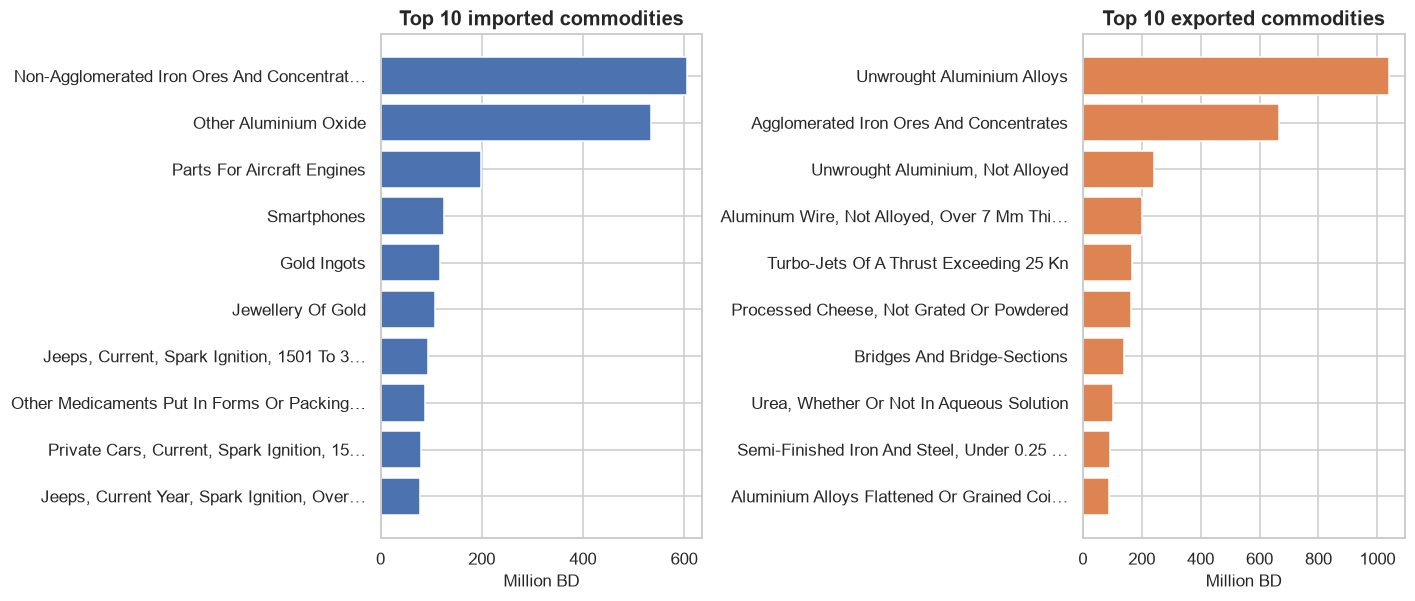

In [18]:
top_imp_comm = imp24.groupby("commodity")["value_bd"].sum().sort_values(ascending=False).head(10) / 1e6
top_exp_comm = texp24.groupby("commodity")["value_bd"].sum().sort_values(ascending=False).head(10) / 1e6

def short(labels, n=42):
    return [l if len(l) <= n else l[:n-1] + "…" for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
axes[0].barh(short(top_imp_comm.index[::-1]), top_imp_comm.values[::-1], color=C_IMPORT)
axes[0].set_title("Top 10 imported commodities")
axes[1].barh(short(top_exp_comm.index[::-1]), top_exp_comm.values[::-1], color=C_EXPORT)
axes[1].set_title("Top 10 exported commodities")
for ax in axes:
    ax.set_xlabel("Million BD")
plt.tight_layout()
plt.savefig(IMAGES / "obj4_top_commodities.png")
plt.show()

**Insight.** Bahrain's non-oil trade is a **metals value-chain**: the biggest **imports** are **iron ore and
alumina** (feedstock), while the biggest **exports** are **unwrought aluminium and iron/steel products**. The
country buys raw materials, refines them with cheap energy, and sells the finished metal — the essence of its
industrial diversification.

#### Objective 5 — How concentrated is non-oil trade? (Pareto)

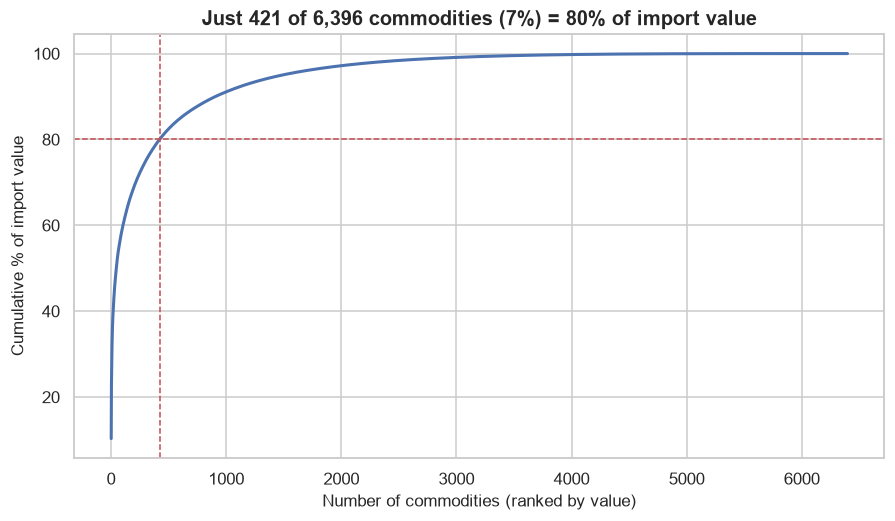

421 commodities (6.6% of 6,396) make up 80% of import value.


In [19]:
comm_imp = imp24.groupby("commodity")["value_bd"].sum().sort_values(ascending=False)
cum_share = comm_imp.cumsum() / comm_imp.sum()
n80 = int((cum_share <= 0.80).sum() + 1)
pct_comm = n80 / len(comm_imp) * 100

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(np.arange(1, len(cum_share)+1), cum_share.values * 100, color=C_IMPORT, lw=2)
ax.axhline(80, color=C_NEG, ls="--", lw=1)
ax.axvline(n80, color=C_NEG, ls="--", lw=1)
ax.set_title(f"Just {n80} of {len(comm_imp):,} commodities ({pct_comm:.0f}%) = 80% of import value")
ax.set_xlabel("Number of commodities (ranked by value)")
ax.set_ylabel("Cumulative % of import value")
plt.savefig(IMAGES / "obj5_concentration.png")
plt.show()
print(f"{n80} commodities ({pct_comm:.1f}% of {len(comm_imp):,}) make up 80% of import value.")

**Insight.** Non-oil imports are **highly concentrated** — around **7% of commodity lines account for 80% of
value**. A small set of products (and the industries behind them) therefore drives most of Bahrain's trade
exposure.

#### Objective 6 — Seasonality: monthly trade in 2024

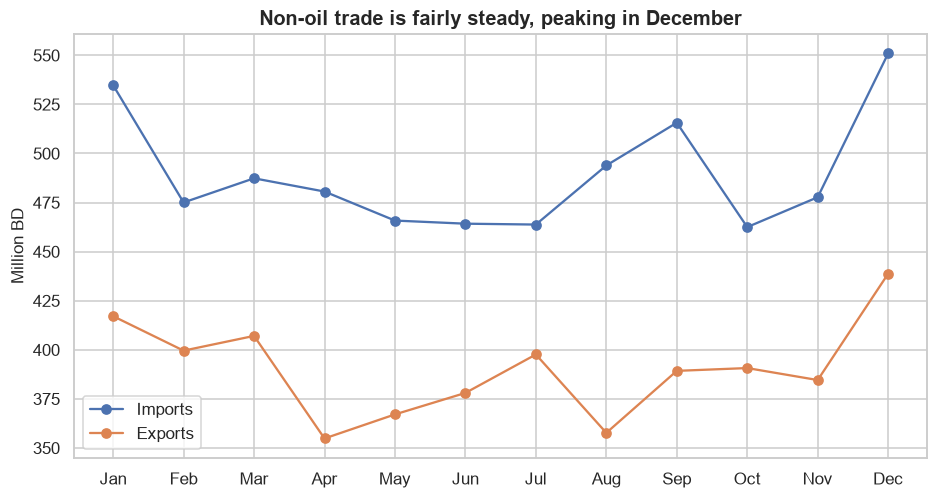

Imports  range: 463 - 551 M BD
Exports  range: 355 - 439 M BD


In [20]:
mi = imp24.groupby("month_num")["value_bd"].sum() / 1e6
me = texp24.groupby("month_num")["value_bd"].sum() / 1e6
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1,13), mi.reindex(range(1,13)).values, marker="o", color=C_IMPORT, label="Imports")
ax.plot(range(1,13), me.reindex(range(1,13)).values, marker="o", color=C_EXPORT, label="Exports")
ax.set_xticks(range(1,13)); ax.set_xticklabels(months)
ax.set_title("Non-oil trade is fairly steady, peaking in December")
ax.set_ylabel("Million BD")
ax.legend()
plt.savefig(IMAGES / "obj6_seasonality.png")
plt.show()
print("Imports  range:", f"{mi.min():,.0f} - {mi.max():,.0f} M BD")
print("Exports  range:", f"{me.min():,.0f} - {me.max():,.0f} M BD")

**Insight.** There is **no dramatic seasonality**: monthly imports stay in a ~460–550 M BD band and exports
~355–440 M BD, with a mild **December peak** in both. Trade volumes are structurally stable month to month.

#### Objective 7 — What changed between 2023 and 2024?

In [21]:
# Year-on-year change in total value, and biggest commodity movers (imports)
yoy = pd.DataFrame({
    "Imports": [imp23["value_bd"].sum()/1e6, imp24["value_bd"].sum()/1e6],
    "Exports": [texp23["value_bd"].sum()/1e6, texp24["value_bd"].sum()/1e6],
}, index=[2023, 2024])
print("Year-on-year totals (million BD):")
print(yoy.round(0))
print("Imports change:", f"{(yoy.loc[2024,'Imports']/yoy.loc[2023,'Imports']-1)*100:+.1f}%")
print("Exports change:", f"{(yoy.loc[2024,'Exports']/yoy.loc[2023,'Exports']-1)*100:+.1f}%")

# Biggest movers by commodity (merge 2023 vs 2024, mask to material lines, sort)
c23 = imp23.groupby("commodity")["value_bd"].sum().div(1e6).rename("y2023")
c24 = imp24.groupby("commodity")["value_bd"].sum().div(1e6).rename("y2024")
movers = pd.concat([c23, c24], axis=1).fillna(0)
movers["change"] = movers["y2024"] - movers["y2023"]
movers = movers[movers[["y2023", "y2024"]].max(axis=1) > 20]     # mask to material commodities
top_up   = movers.sort_values("change", ascending=False).head(5)
top_down = movers.sort_values("change").head(5)
print("\nBiggest import risers 2023->2024 (M BD):")
print(top_up["change"].round(0))
print("\nBiggest import fallers 2023->2024 (M BD):")
print(top_down["change"].round(0))

Year-on-year totals (million BD):
      Imports  Exports
2023   5778.0   4665.0
2024   5872.0   4682.0
Imports change: +1.6%
Exports change: +0.4%

Biggest import risers 2023->2024 (M BD):
commodity
Other Aluminium Oxide                                  87.0
Parts For Aircraft Engines                             54.0
Jeeps, Current, Spark Ignition, 1501 To 3000 Cc        25.0
Jewellery Of Gold                                      15.0
Cathodes And Sections Of Cathodes Of Refined Copper    15.0
Name: change, dtype: float64

Biggest import fallers 2023->2024 (M BD):
commodity
Gold Ingots                                                                                                                                                                                                  -104.0
Petroleum Coke Not Calcined                                                                                                                                                                                   -

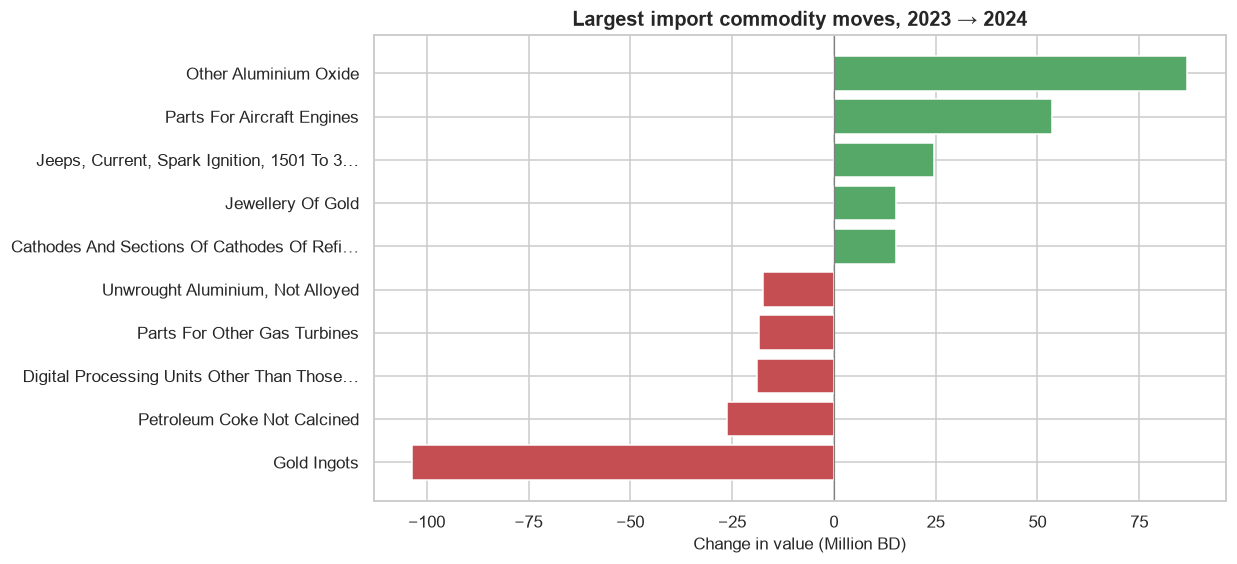

In [22]:
movers_plot = pd.concat([top_up, top_down]).sort_values("change")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(short(movers_plot.index.tolist()), movers_plot["change"].values,
        color=[C_POS if v >= 0 else C_NEG for v in movers_plot["change"]])
ax.axvline(0, color="grey", lw=0.8)
ax.set_title("Largest import commodity moves, 2023 → 2024")
ax.set_xlabel("Change in value (Million BD)")
plt.savefig(IMAGES / "obj7_yoy_movers.png")
plt.show()

**Insight.** Total non-oil imports and exports were **broadly stable** year-on-year, but underneath the
surface individual commodities moved sharply — useful early-warning signals of shifting industrial demand.

#### Inferential statistics
We move beyond description to test two hypotheses on the 2024 transaction data.

In [23]:
# (1) Is transaction VALUE associated with shipment WEIGHT?  Pearson correlation on log scale.
s = imp24[["value_bd", "weight_kg"]].dropna()
s = s[(s["value_bd"] > 0) & (s["weight_kg"] > 0)]
r, p = stats.pearsonr(np.log10(s["value_bd"]), np.log10(s["weight_kg"]))
print(f"(1) Pearson r[log(value), log(weight)] = {r:.3f}  (p = {p:.1e}, n = {len(s):,})")
print("    -> strong, statistically significant positive association.\n")

# (2) Do IMPORT and EXPORT transactions differ in typical size?  Welch's t-test on log value.
li = np.log10(imp24["value_bd"][imp24["value_bd"] > 0])
le = np.log10(texp24["value_bd"][texp24["value_bd"] > 0])
t, p2 = stats.ttest_ind(li, le, equal_var=False)
print(f"(2) Welch t-test log(value) imports vs exports: t = {t:.1f} (p = {p2:.1e})")
print(f"    median import = {10**li.median():,.0f} BD | median export = {10**le.median():,.0f} BD")

# (3) 95% confidence interval for the mean import transaction value
m, sd, n = imp24["value_bd"].mean(), imp24["value_bd"].std(), len(imp24)
ci = stats.t.interval(0.95, n-1, loc=m, scale=sd/np.sqrt(n))
print(f"\n(3) Mean import transaction = {m:,.0f} BD, 95% CI [{ci[0]:,.0f}, {ci[1]:,.0f}]")

(1) Pearson r[log(value), log(weight)] = 0.788  (p = 0.0e+00, n = 321,766)
    -> strong, statistically significant positive association.

(2) Welch t-test log(value) imports vs exports: t = -16.8 (p = 1.5e-63)
    median import = 684 BD | median export = 752 BD

(3) Mean import transaction = 18,234 BD, 95% CI [16,854, 19,613]


**Insight.** Transaction **value and weight are strongly and significantly correlated** (r ≈ 0.79, p ≈ 0),
confirming the data behaves sensibly. Import and export **transaction sizes differ significantly** — a reminder
that the two flows have different underlying structures (bulk raw-material imports vs varied exports).

---
## Summary
**Summarizing the key insights from the analysis**

* Bahrain's **overall** trade balance recovered from **five deficit years (2016–2020)** to a **record surplus in
  2022** — but this is **heavily oil-driven**.
* Stripping out oil, Bahrain ran a **non-oil trade deficit of ≈ 1,190 M BD in 2024** (imports ≈ 5,872 M vs exports
  ≈ 4,682 M BD).
* **~83% of exports are national-origin**, so the export base reflects genuine domestic production, not just
  re-exports.
* Non-oil trade is a **metals value-chain**: top imports are **iron ore & alumina**; top exports are **aluminium &
  steel products**.
* **Exports are regionally concentrated** (Saudi Arabia + UAE lead; top-5 ≈ 54%); imports are more diversified
  (China, Australia, Brazil).
* Trade is **commodity-concentrated** — ~**7% of commodities = 80% of value** — and **seasonally stable** with a
  mild December peak.
* Value and weight are **strongly, significantly correlated** (r ≈ 0.79).

## Recommendations/Conclusion

**Recommendations (data-driven):**
* **Target the non-oil deficit through import-substitution** in the largest import lines (iron ore, alumina,
  vehicles, electronics) where domestic or regional value-addition is feasible.
* **Deepen the aluminium & steel value-chain** — it is already Bahrain's export engine; expanding downstream
  products would raise export value without new raw-material dependence.
* **Diversify export destinations** beyond Saudi Arabia and the UAE (top-5 ≈ 54%) to reduce concentration risk,
  building on existing links to the USA, Netherlands and India.
* **Monitor the concentrated commodity set** (the ~7% of lines that drive 80% of value) as a leading indicator of
  industrial demand shifts.

**Next steps / areas for further research:**
* Extend the transaction analysis across **2020–2026** for a full multi-year panel and trend modelling.
* Add **oil-trade** data to reconcile the non-oil view with the headline totals.
* Adjust monetary values for **inflation** to compare real trade volumes over time.
* Enrich partner analysis with **trade-agreement** and **distance/GDP** data (a gravity-model extension).

**Limitations.** The transaction datasets are **non-oil only** and cover **2023–2024**; annual totals are
**nominal** (not inflation-adjusted) and **oil-inclusive**, so the two views must not be compared like-for-like.